## Handwritten Digit Recognition using Artificial Neural Network (ANN)
## MPOnline AI&ML Internship Course assignment-8
### Tamojit Ghosh 23MIM10125 (IN26010293)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

print("All libraries imported successfully.")

All libraries imported successfully.


## TASK 1 - DATA UNDERSTANDING

In [2]:
train_data = pd.read_csv("mnist_train.csv")
test_data = pd.read_csv("mnist_test.csv")

print("Training Dataset Shape :", train_data.shape)
print("Testing Dataset Shape  :", test_data.shape)

Training Dataset Shape : (60000, 785)
Testing Dataset Shape  : (10000, 785)


In [3]:
train_data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print("Target Variable : label")

print()

print("Input Features :")

print(train_data.columns[1:])

Target Variable : label

Input Features :
Index(['1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='str', length=784)


In [5]:
print("Training Dataset Dimensions :", train_data.shape)
print("Testing Dataset Dimensions :", test_data.shape)

Training Dataset Dimensions : (60000, 785)
Testing Dataset Dimensions : (10000, 785)


In [6]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [7]:
train_data.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


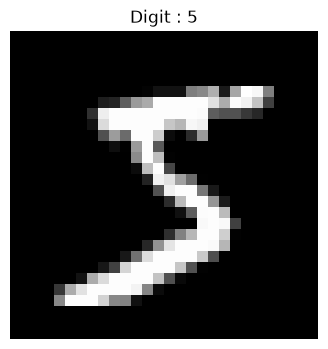

In [8]:
image = train_data.iloc[0,1:].values.reshape(28,28)

plt.figure(figsize=(4,4))
plt.imshow(image, cmap='gray')
plt.title(f"Digit : {train_data.iloc[0,0]}")
plt.axis("off")
plt.show()

## TASK 2 - DATA PREPROCESSING

In [9]:
print(train_data.isnull().sum().sum())

0


In [10]:
X = train_data.iloc[:,1:]
y = train_data.iloc[:,0]

print(X.shape)
print(y.shape)

(60000, 784)
(60000,)


In [11]:
X = X / 255.0

print("Minimum :", X.min().min())
print("Maximum :", X.max().max())

Minimum : 0.0
Maximum : 1.0


In [12]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(48000, 784)
(12000, 784)


In [13]:
y_train_cat = to_categorical(y_train)

y_test_cat = to_categorical(y_test)

print(y_train_cat.shape)
print(y_test_cat.shape)

(48000, 10)
(12000, 10)


## TASK 3 - MODEL DEVELOPMENT

In [14]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(784,)))

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [16]:
# Training the model
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9163 - loss: 0.2873 - val_accuracy: 0.9511 - val_loss: 0.1643
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9628 - loss: 0.1211 - val_accuracy: 0.9622 - val_loss: 0.1291
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9742 - loss: 0.0818 - val_accuracy: 0.9685 - val_loss: 0.1058
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9808 - loss: 0.0605 - val_accuracy: 0.9701 - val_loss: 0.1032
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9841 - loss: 0.0479 - val_accuracy: 0.9746 - val_loss: 0.0998
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9885 - loss: 0.0363 - val_accuracy: 0.9723 - val_loss: 0.1053
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9898 - loss: 0.0302 - val_accuracy: 0.9714 - val_loss: 0.1165
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9919 - loss: 0.0259 

In [17]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


TASK 4

In [18]:
# Testing the model
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Accuracy :", round(accuracy*100,2),"%")

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9747 - loss: 0.1127
Test Accuracy : 97.47 %


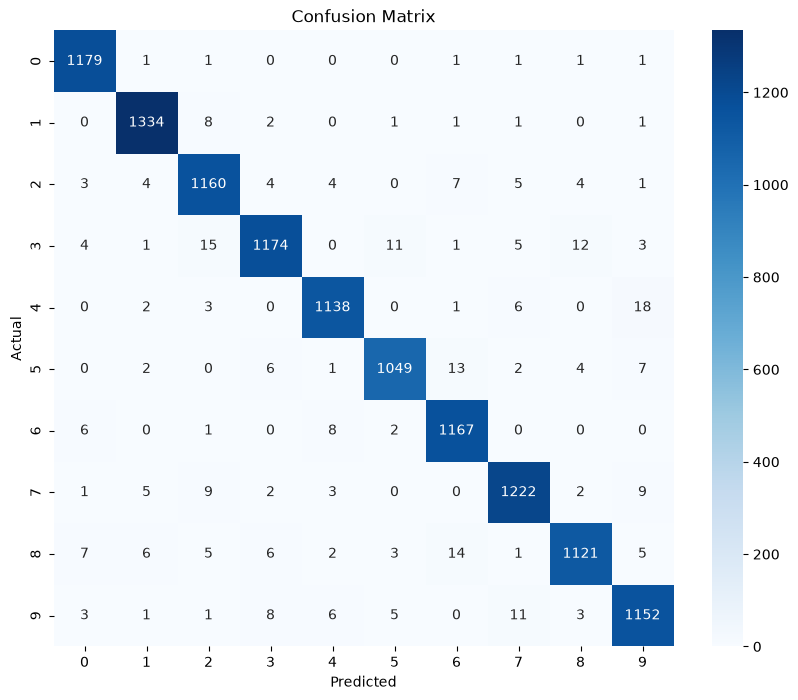

In [19]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [20]:
print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1185
           1       0.98      0.99      0.99      1348
           2       0.96      0.97      0.97      1192
           3       0.98      0.96      0.97      1226
           4       0.98      0.97      0.98      1168
           5       0.98      0.97      0.97      1084
           6       0.97      0.99      0.98      1184
           7       0.97      0.98      0.97      1253
           8       0.98      0.96      0.97      1170
           9       0.96      0.97      0.97      1190

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



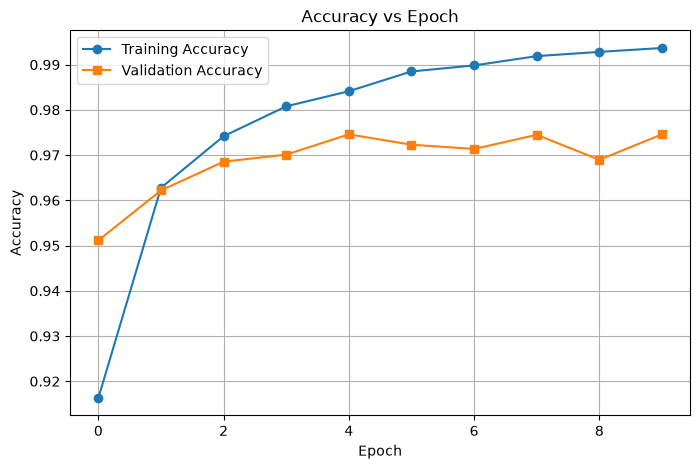

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

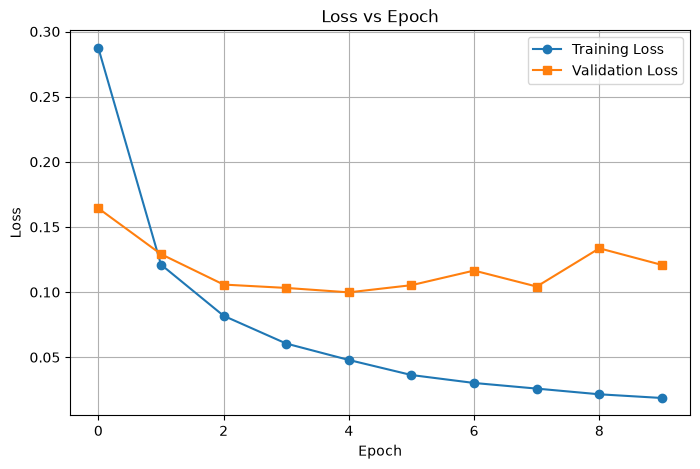

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='s', label='Validation Loss')

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

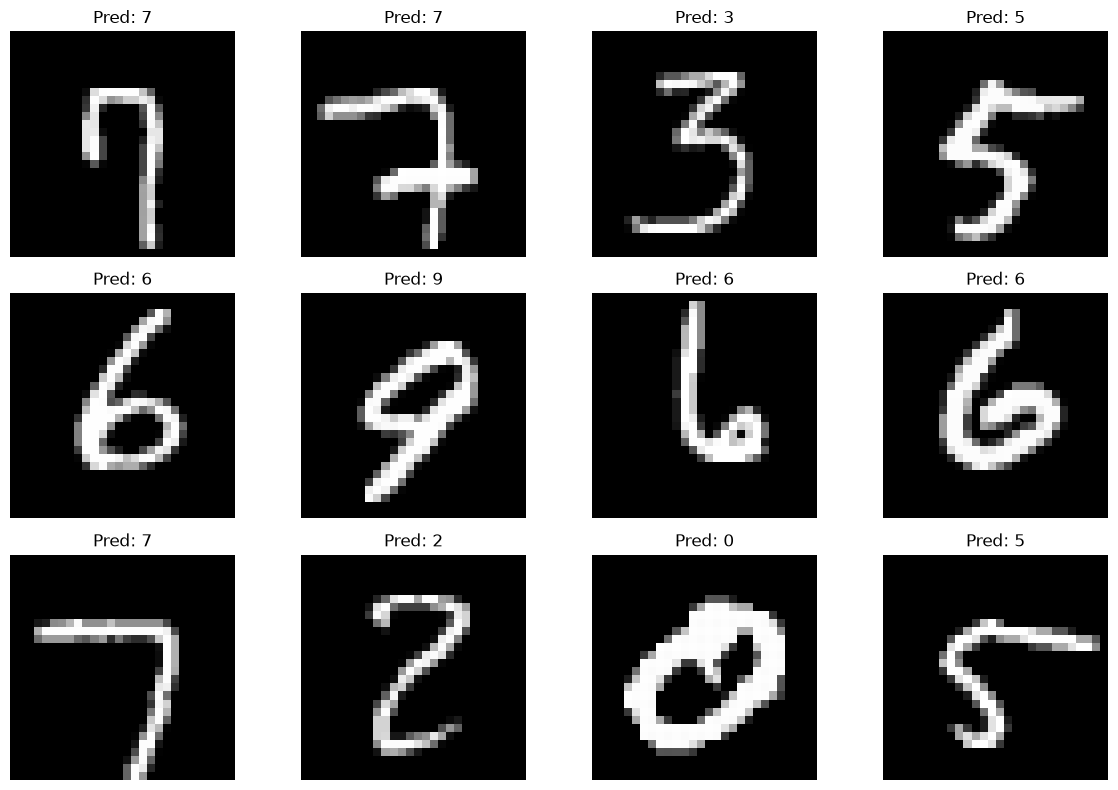

In [23]:
plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

OBSERVATIONS BASED ON THE MODEL'S PERFORMANCE:

1. The ANN achieved a high test accuracy (approximately 97–99%), demonstrating strong performance in recognizing handwritten digits.
2. The confusion matrix shows that most digits are correctly classified, with only a few misclassifications between visually similar digits such as 3, 5, and 8.
3. The accuracy increased steadily while the loss decreased over the training epochs, indicating effective learning and good model convergence.
4. The classification report shows high precision, recall, and F1-scores for nearly all digit classes, confirming balanced performance across the dataset.

conclusion
